# Diabetes - Multi-Layer Perceptron (MLP) with Keras

### Imports and Setup

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

diabetes_dataframe_training = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

X_train = diabetes_dataframe_training.drop('Diabetes_binary', axis=1)
y_train = diabetes_dataframe_training['Diabetes_binary']

diabetes_dataframe_training.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [2]:
diabetes_dataframe_testing = pd.read_csv('..\\diabetes_dataset(s)\\diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

X_test = diabetes_dataframe_testing.drop('Diabetes_binary', axis=1)
y_test = diabetes_dataframe_testing['Diabetes_binary']

diabetes_dataframe_testing.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
# Check for number of unique values in each column (for categorical variables)
diabetes_dataframe_training.nunique()

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     80
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

### Data Preprocessing

Seems the dataset will require encoding, as almost all features are categorical. We will use OneHotEncoder for the nominal features and OrdinalEncoder for the ordinal features.

In [4]:
# make prerocessor
preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(), ['Income', 'Education', 'Age', 'GenHlth',]),
    ('nominal', OneHotEncoder(), ['Sex','DiffWalk', 'NoDocbcCost', 'AnyHealthcare', 'HvyAlcoholConsump', 'Veggies', 'Fruits', 'PhysActivity', 
                                  'HeartDiseaseorAttack', 'Stroke', 'Smoker', 'CholCheck', 'HighChol', 'HighBP']),
    ('numerical', StandardScaler(), ['PhysHlth', 'MentHlth', 'BMI'])
])

# process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.fit_transform(X_test)

# check the shape of the processed data
X_train_processed.shape, X_test_processed.shape

((70692, 35), (70692, 35))

### Build the Multi-Layer Perceptron (MLP) Model

With one layer and 100 nodes

In [5]:
processing = layers.Normalization(axis=-1)
processing.adapt(X_train_processed)

In [6]:
# Implement MLP with one hidden layer with 100 nodes and the relu activation function 

# convert to tensors due to compatibility issue
X_train_processed = tf.convert_to_tensor(X_train_processed, dtype=tf.float32)
X_test_processed = tf.convert_to_tensor(X_test_processed, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)


one_layer_model = keras.Sequential([
    layers.Dense(100, activation='relu'),
    layers.Dense(1)
])
one_layer_model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
one_layer_model.fit(X_train_processed, y_train, validation_split=0.2, verbose=0, epochs=100)

2 hidden layers with 100 nodes each

In [7]:
two_layer_model = keras.Sequential([
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1)
])
two_layer_model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
two_layer_model.fit(X_train_processed, y_train, validation_split=0.2, verbose=0, epochs=100)

3 hidden layers with 100 nodes each

In [8]:
three_layer_model = keras.Sequential([
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(1)
])
three_layer_model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
three_layer_model.fit(X_train_processed, y_train, validation_split=0.2, verbose=0, epochs=100)

4 hidden layers with 200 nodes each

In [12]:
four_layer_model = keras.Sequential([
    layers.Dense(200, activation='relu'),
    layers.Dense(200, activation='relu'),
    layers.Dense(200, activation='relu'),
    layers.Dense(200, activation='relu'),
    layers.Dense(1)
])
four_layer_model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
four_layer_model.fit(X_train_processed, y_train, validation_split=0.2, verbose=0, epochs=100)

5 hidden layers with 200 nodes each

In [23]:
five_layer_model = keras.Sequential([
    layers.Dense(300, activation='relu'),
    layers.Dense(300, activation='relu'),
    layers.Dense(300, activation='relu'),
    layers.Dense(300, activation='relu'),
    layers.Dense(300, activation='relu'),
    layers.Dense(1)
])
five_layer_model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])
five_layer_model.fit(X_train_processed, y_train, validation_split=0.2, verbose=0, epochs=100)

### Compare Models

In [24]:
one_layer_test_loss, one_layer_test_acc = one_layer_model.evaluate(X_test_processed, y_test, batch_size=10, verbose=0)
print(f"One Layer Model Test Loss: {one_layer_test_loss:.4f}, Test Accuracy: {one_layer_test_acc:.4f}")

two_layer_test_loss, two_layer_test_acc = two_layer_model.evaluate(X_test_processed, y_test, batch_size=10, verbose=0)
print(f"Two Layer Model Test Loss: {two_layer_test_loss:.4f}, Test Accuracy: {two_layer_test_acc:.4f}")

three_layer_test_loss, three_layer_test_acc = three_layer_model.evaluate(X_test_processed, y_test, batch_size=10, verbose=0)
print(f"Three Layer Model Test Loss: {three_layer_test_loss:.4f}, Test Accuracy: {three_layer_test_acc:.4f}")

four_layer_test_loss, four_layer_test_acc = four_layer_model.evaluate(X_test_processed, y_test, batch_size=10, verbose=0)
print(f"Four Layer Model Test Loss: {four_layer_test_loss:.4f}, Test Accuracy: {four_layer_test_acc:.4f}")

five_layer_test_loss, five_layer_test_acc = five_layer_model.evaluate(X_test_processed, y_test, batch_size=10, verbose=0)
print(f"Five Layer Model Test Loss: {five_layer_test_loss:.4f}, Test Accuracy: {five_layer_test_acc:.4f}")

One Layer Model Test Loss: 0.5183, Test Accuracy: 0.6884
Two Layer Model Test Loss: 0.5121, Test Accuracy: 0.7536
Three Layer Model Test Loss: 0.5656, Test Accuracy: 0.7734
Four Layer Model Test Loss: 0.6063, Test Accuracy: 0.8039
Five Layer Model Test Loss: 0.8220, Test Accuracy: 0.8214


In [25]:
# Get predictions
y_pred_one_layer = one_layer_model.predict(X_test_processed)
y_pred_two_layer = two_layer_model.predict(X_test_processed)
y_pred_three_layer = three_layer_model.predict(X_test_processed)
y_pred_four_layer = four_layer_model.predict(X_test_processed)
y_pred_five_layer = five_layer_model.predict(X_test_processed)

# Convert logits to binary predictions
y_pred_one_layer_binary = (y_pred_one_layer > 0.5).astype(int)
y_pred_two_layer_binary = (y_pred_two_layer > 0.5).astype(int)
y_pred_three_layer_binary = (y_pred_three_layer > 0.5).astype(int)
y_pred_four_layer_binary = (y_pred_four_layer > 0.5).astype(int)
y_pred_five_layer_binary = (y_pred_five_layer > 0.5).astype(int)

# Print classification report and confusion matrix for each model
print("One Layer Model Classification Report:")
print(classification_report(y_test, y_pred_one_layer_binary))
print("One Layer Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_one_layer_binary))

2210/2210 [==============================] - 2s 937us/step
One Layer Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.92      0.75     35346
         1.0       0.85      0.46      0.59     35346

    accuracy                           0.69     70692
   macro avg       0.74      0.69      0.67     70692
weighted avg       0.74      0.69      0.67     70692

One Layer Model Confusion Matrix:
[[32530  2816]
 [19212 16134]]


In [26]:
print("Two Layer Model Classification Report:")
print(classification_report(y_test, y_pred_two_layer_binary))
print("Two Layer Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_two_layer_binary))


Two Layer Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.93      0.79     35346
         1.0       0.89      0.58      0.70     35346

    accuracy                           0.75     70692
   macro avg       0.79      0.75      0.75     70692
weighted avg       0.79      0.75      0.75     70692

Two Layer Model Confusion Matrix:
[[32917  2429]
 [14989 20357]]


In [27]:
print("Three Layer Model Classification Report:")
print(classification_report(y_test, y_pred_three_layer_binary))
print("Three Layer Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_three_layer_binary))

Three Layer Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.95      0.81     35346
         1.0       0.92      0.60      0.73     35346

    accuracy                           0.77     70692
   macro avg       0.81      0.77      0.77     70692
weighted avg       0.81      0.77      0.77     70692

Three Layer Model Confusion Matrix:
[[33428  1918]
 [14099 21247]]


In [28]:
print("Four Layer Model Classification Report:")
print(classification_report(y_test, y_pred_four_layer_binary))
print("Four Layer Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_three_layer_binary))

Four Layer Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.95      0.83     35346
         1.0       0.94      0.65      0.77     35346

    accuracy                           0.80     70692
   macro avg       0.83      0.80      0.80     70692
weighted avg       0.83      0.80      0.80     70692

Four Layer Model Confusion Matrix:
[[33428  1918]
 [14099 21247]]


In [29]:
print("Five Layer Model Classification Report:")
print(classification_report(y_test, y_pred_five_layer_binary))
print("Five Layer Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_five_layer_binary))

Five Layer Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.95      0.84     35346
         1.0       0.94      0.69      0.79     35346

    accuracy                           0.82     70692
   macro avg       0.85      0.82      0.82     70692
weighted avg       0.85      0.82      0.82     70692

Five Layer Model Confusion Matrix:
[[33730  1616]
 [11013 24333]]


while the MLP with 5 layers is performing the best, it is also the most complex, requiring more time to train and more resources, and with performance that is not significantly better than the previous model. Therefore, we will use the 4-layer model to generate some plots.

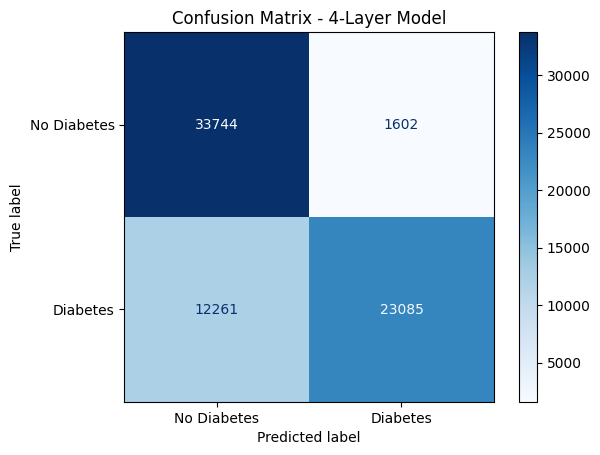

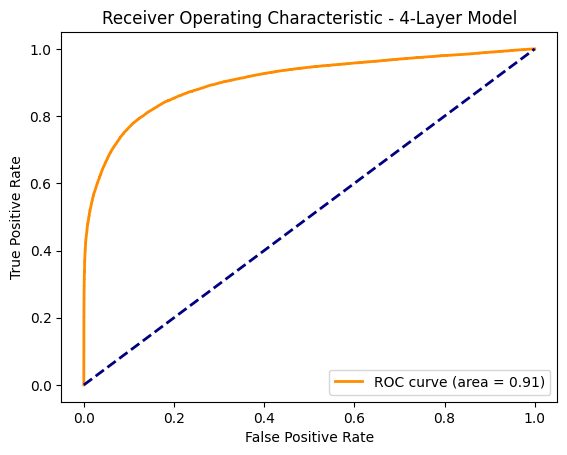

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

import matplotlib.pyplot as plt

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test.numpy(), y_pred_four_layer_binary, display_labels=["No Diabetes", "Diabetes"], cmap=plt.cm.Blues)
plt.title("Confusion Matrix - 4-Layer Model")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test.numpy(), y_pred_four_layer)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic - 4-Layer Model")
plt.legend(loc="lower right")
plt.show()

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calculate metrics
accuracy = accuracy_score(y_test.numpy(), y_pred_four_layer_binary)
precision = precision_score(y_test.numpy(), y_pred_four_layer_binary)
recall = recall_score(y_test.numpy(), y_pred_four_layer_binary)
f1 = f1_score(y_test.numpy(), y_pred_four_layer_binary)
roc_auc = roc_auc_score(y_test.numpy(), y_pred_four_layer)

# Print metrics
print(f"4-Layer Model Accuracy: {accuracy:.4f}")
print(f"4-Layer Model Precision: {precision:.4f}")
print(f"4-Layer Model Recall: {recall:.4f}")
print(f"4-Layer Model F1 Score: {f1:.4f}")
print(f"4-Layer Model ROC AUC: {roc_auc:.4f}")

4-Layer Model Accuracy: 0.8039
4-Layer Model Precision: 0.9351
4-Layer Model Recall: 0.6531
4-Layer Model F1 Score: 0.7691
4-Layer Model ROC AUC: 0.9056
